In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


mortality = pd.read_excel("data/UNIGME-2025-UNICEFRegion-Rates-Deaths-Sex-specific-5-to-24.xlsx",sheet_name="20q5, 10q10",skiprows=14)

mortality.columns = mortality.columns.str.strip()

mortality = mortality[["Region", "Sex", "Year", "Median"]] #data analizi için only relevant variablesları seçtim

mortality = mortality.rename(columns={
    "Median": "mort_median_5_24"
})

mortality = mortality.groupby(["Region", "Year"])["mort_median_5_24"].mean().reset_index()
# veriyi region + year bazında ortalama alarak özetliyoruz, ayrıca bu adımla sex ve region level kısmını datasetten çıkardık
hdi = pd.read_excel(
    "data/HDR25_Statistical_Annex_HDI_Table.xlsx",
    skiprows=4,
    usecols="B:C"
)




mapping = pd.read_excel("data/JME_Regional-Classifications.xlsx")

mapping = mapping[["Country", "UNICEF Region"]]
#mapping = mapping.rename(columns={"UNICEF Region": " UNICEF Region"})
mapping.head()
econ = pd.read_excel(
    "data/19-Economic-Indicators-SOWC2025-1.xlsx",
    skiprows=6,
    header=None,
    usecols=[1, 6, 8]
)

econ.columns = ["Country", "health_spending", "education_spending"]

econ = econ.iloc[1:].reset_index(drop=True)

econ["health_spending"] = pd.to_numeric(econ["health_spending"], errors="coerce")
econ["education_spending"] = pd.to_numeric(econ["education_spending"], errors="coerce")

econ = econ.merge(mapping, on="Country", how="left")#burada econ datasındaki ülkelere, mapping datasından hangi bölgeye ait olduklarını ekledik
econ.head()
hdi.columns = ["Country", "HDI"]
hdi = hdi.iloc[2:].reset_index(drop=True)#gereksiz satırları silip index’i resetledim
hdi.head()
hdi = hdi.merge(mapping, on="Country", how="left")#burada da HDI verisindeki ülkelere hangi bölgeye ait olduklarını ekledik
hdi.head()
hdi = hdi.rename(columns={"UNICEF Region": "Region"})
hdi["HDI"] = pd.to_numeric(hdi["HDI"], errors="coerce")

hdi_region = hdi.groupby("Region")["HDI"].mean().reset_index()#ülkeleri bölgelere göre gruplayıp ortalama HDI hesaplıyoruz
hdi_region.head(10)


region_map = {
    "EAPRO": "East Asia and Pacific",
    "ECA": "Europe and Central Asia",
    "LACRO": "Latin America and Caribbean",
    "MENA": "Middle East and North Africa",
    "ROSA": "South Asia",
    "SSA": "Sub-Saharan Africa"
}
#burada kısaltılmış region kodlarını tam isimlere çevirmek için mapping oluşturdum(gpt söyledi)
hdi_region["Region"] = hdi_region["Region"].replace(region_map)
hdi_region

econ_region = econ.groupby("UNICEF Region")[["health_spending", "education_spending"]].mean().reset_index()
econ_region["UNICEF Region"] = econ_region["UNICEF Region"].replace(region_map)
econ_region = econ_region.rename(columns={"UNICEF Region": "Region"}) #Ülkeleri bölgelere göre gruplayıp: health spending ortalaması ve education spending ortalaması aldık
#(groupby ile)

df = mortality.merge(hdi_region, on="Region", how="left") #burada mortality datasına hdi ekledim
df = df.merge(econ_region, on="Region", how="left")#burada da economic verileri ekledim

df.head()
df.isnull().sum()#merge sonrası verileri kontrol eder her sütun biribriyle eşleniyor mu boş veri var mı diye

fix_map = {
    "Eastern Europe and Central Asia": "Europe and Central Asia",
    "Western Europe": "Europe and Central Asia",
    "Eastern and Southern Africa": "Sub-Saharan Africa",
    "West and Central Africa": "Sub-Saharan Africa",
    "North America": "Europe and Central Asia",  # approx (dataset'e göre kabul)
    "World": None  # bunu istemiyoruz
}

df["Region"] = df["Region"].replace(fix_map)#mortality datasetindeki region isimlerini diğer datasetlerle uyumlu hale getirdik
df = mortality.copy()
df["Region"] = df["Region"].replace(fix_map)

df = df.merge(hdi_region, on="Region", how="left")
df = df.merge(econ_region, on="Region", how="left")
df.isnull().sum()
df = df[df["Region"].notna()].reset_index(drop=True)# burada region değeri boş (NaN) olan satırları sildik, sonra index’i sıfırlayıp düzenledik
df.isnull().sum()






Region                0
Year                  0
mort_median_5_24      0
HDI                   0
health_spending       0
education_spending    0
dtype: int64

###EXPLORATORY DATA ANALYSIS AND HYPOTHESIS TESTING – YOUTH MORTALITY AND SOCIO-ECONOMIC FACTORS

This part of the notebook presents the main exploratory data analysis (EDA) and hypothesis testing for the project.

**Understanding Youth Mortality: The Role of Socio-Economic Development Across Regions**

The goal of this analysis is to explore how youth mortality rates (ages 5–24) are related to socio-economic factors such as the Human Development Index (HDI), health spending, and education spending. In addition, the analysis examines regional differences in mortality outcomes.

The notebook is organised as follows:

- Data loading, cleaning, and merging from multiple sources  
- Descriptive statistics and data validation  
- Relationship between HDI and mortality (H1)  
- Statistical testing (correlation, t-test, ANOVA)  
- Economic indicators and mortality (H2)  
- Regional differences in mortality rates (H3)

In [3]:
df.describe()#burada da tüm data cleaning işlemleri sonucundaki özet istatistikleri veriyor

,Year,mort_median_5_24,HDI,health_spending,education_spending
count,385.000000,385.000000,385.000000,385.000000,385.000000
mean,2007.000000,24.998897,0.741455,3.919837,4.316662
std,10.112647,21.123060,0.130124,1.734485,0.356637
min,1990.000000,3.720566,0.561587,1.833304,3.786024
25%,1998.000000,9.734127,0.561587,1.833304,3.921891
50%,2007.000000,15.814418,0.768424,4.406373,4.369904
75%,2016.000000,36.756472,0.882796,5.864425,4.702014
max,2024.000000,117.836929,0.882796,5.864425,4.702014


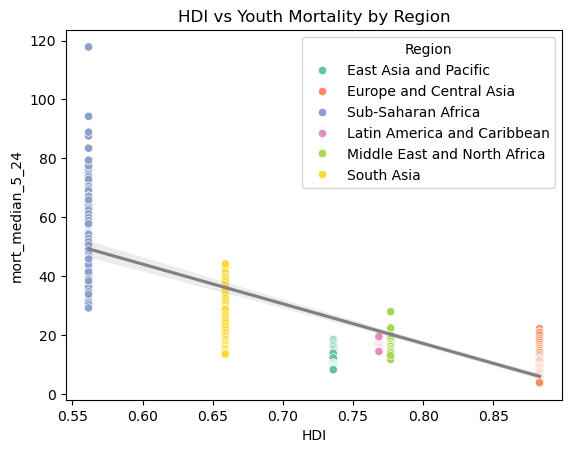

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    hue="Region",
    palette="Set2"
)

sns.regplot(
    data=df,
    x="HDI",
    y="mort_median_5_24",
    scatter=False,
    color="gray"
)

plt.title("HDI vs Youth Mortality by Region")
plt.show()

The scatterplot shows a negative relationship between HDI and youth mortality. Countries with low HDI, especially in Sub-Saharan Africa, have higher and more spread mortality rates. Countries with high HDI, like Europe and Central Asia, have lower and more stable mortality.

This means that as development increases, mortality decreases and becomes more stable.s

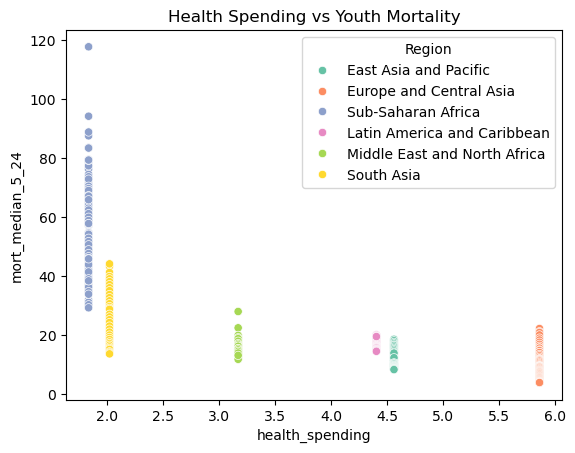

In [5]:
sns.scatterplot(data=df, x="health_spending", y="mort_median_5_24", hue="Region", palette="Set2")
plt.title("Health Spending vs Youth Mortality")
plt.show()

also here the scatter plot shows the relationship between health spending and youth mortality. In general, regions with higher health spending tend to have lower mortality rates. However, this relationship is not very strong. Some regions, like Sub-Saharan Africa, have high mortality even with similar spending levels

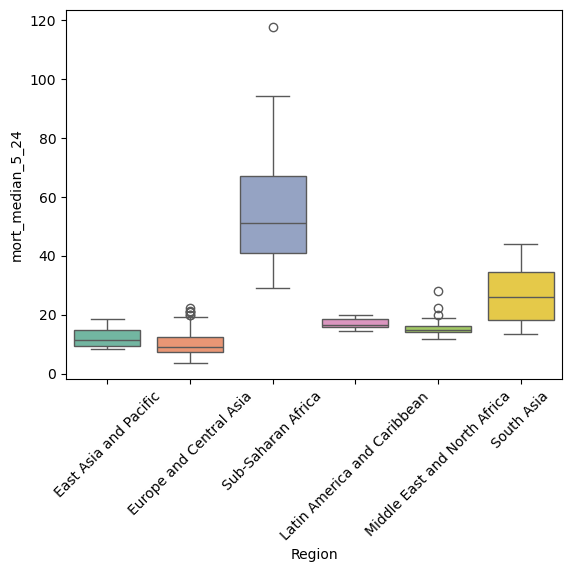

In [6]:
sns.boxplot(data=df, x="Region", y="mort_median_5_24", hue="Region", palette="Set2")
plt.xticks(rotation=45)
plt.show()

 Region-based interpretation

*Sub-Saharan Africa*
	•	Very high median (~50+)
	•	Very wide spread (30 → 120)
👌🏼 worst outcomes + highest uncertainty

⸻

*South Asia*
	•	Moderate levels (~20–40)
👌🏼 developing → still at risk

⸻

*Europe & Central Asia*
	•	Lowest levels (~5–15)
	•	Very stable
👌🏼 best performance

⸻

*East Asia & Pacific / Latin America & Caribbean / Middle East & North Africa*
	•	Low to moderate levels (~10–20)
👌🏼transition regions

**Overall, the boxplot reveals a clear gradient in youth mortality across regions, where more developed regions exhibit both lower and more stable mortality rates, while less developed regions face higher and more variable outcomes.**

In [7]:
df.groupby("Region")["mort_median_5_24"].mean().sort_values() #her bölge için ortalama mortality hesapladık

Region
Europe and Central Asia          9.985477
East Asia and Pacific           12.149831
Middle East and North Africa    15.627380
Latin America and Caribbean     16.945456
South Asia                      26.685995
Sub-Saharan Africa              54.545766
Name: mort_median_5_24, dtype: float64

In [8]:
df[["HDI", "mort_median_5_24"]].corr()#HDI ile mortality arasındaki ilişkiyi sayısal olarak ölçtük

,HDI,mort_median_5_24
HDI,1.000000,-0.830574
mort_median_5_24,-0.830574,1.000000


/var/folders/zc/1c4_8ddx4cs_bz22lc10hc040000gn/T/ipykernel_3131/3296868042.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


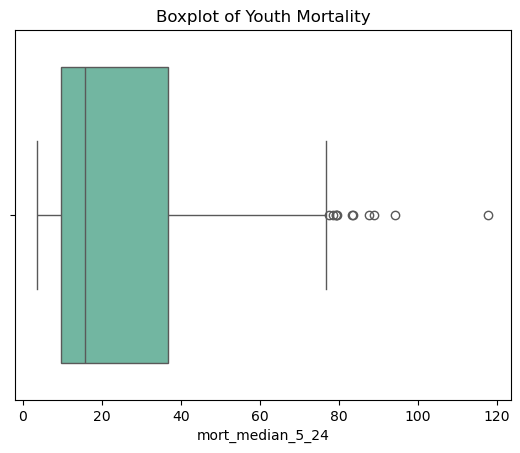

In [11]:
sns.boxplot(
    data=df,
    x="mort_median_5_24",
    palette="Set2"
)

plt.title("Boxplot of Youth Mortality")
plt.show()

The boxplot shows that youth mortality rates are right-skewed, with most observations concentrated at lower values. However, there are several high outliers, indicating that some regions experience significantly higher mortality rates. This suggests that while many regions have relatively low mortality, a small number of regions face much more severe conditions.

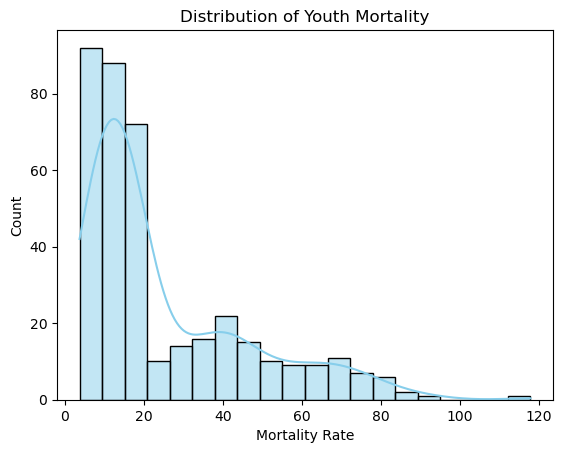

In [12]:
sns.histplot(
    df["mort_median_5_24"],
    kde=True,
    bins=20,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Youth Mortality")
plt.xlabel("Mortality Rate")
plt.ylabel("Count")
plt.show()

The distribution of youth mortality rates is right-skewed, indicating that most regions have relatively low mortality levels, while a smaller number of observations exhibit extremely high values.

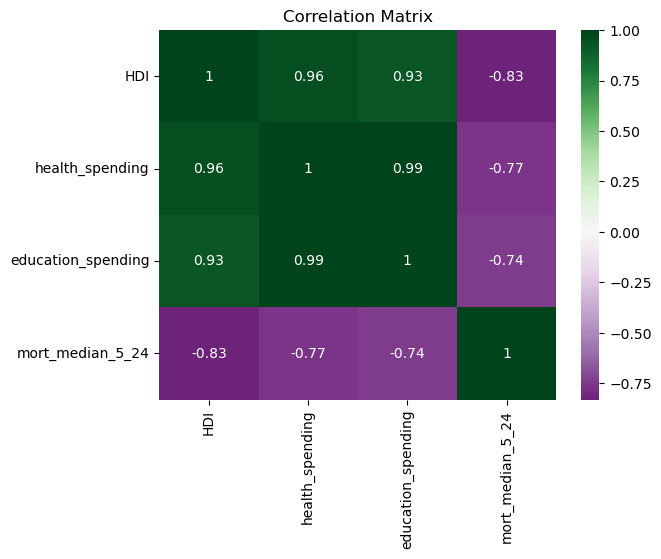

In [13]:
sns.heatmap(
    df[["HDI", "health_spending", "education_spending", "mort_median_5_24"]].corr(),
    annot=True,
    cmap="PRGn",   # pink ↔ green
    center=0
)

plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows strong positive relationships between HDI, health spending, and education spending, indicating that more developed regions invest more in social sectors. Additionally, all three variables have strong negative relationships with youth mortality rates, suggesting that as development and investment increase, mortality rates decrease.